In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from tqdm.notebook import tqdm

tqdm.pandas()


BASE_DIR = Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")

PR_DIR = BASE_DIR / "data" / "processed"
print(f"PR_DIR: {PR_DIR}")

RW_DIR = BASE_DIR / "data" / "raw"
print(f"RW_DIR: {RW_DIR}")

BASE_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2
PR_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2\data\processed
RW_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2\data\raw


# Cargar

In [2]:
r = pd.read_csv(PR_DIR / "cleaned_reviews.csv")

In [3]:
r.head()

,Unnamed: 0,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


# Revisar datos

In [5]:
r.info()

<class 'pandas.DataFrame'>
RangeIndex: 9810 entries, 0 to 9809
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  9810 non-null   int64  
 1   Restaurant  9810 non-null   str    
 2   Reviewer    9810 non-null   str    
 3   Review      9810 non-null   str    
 4   Rating      9810 non-null   int64  
 5   Metadata    9810 non-null   str    
 6   Time        9810 non-null   str    
 7   Pictures    9810 non-null   int64  
 8   7514        1 non-null      float64
dtypes: float64(1), int64(3), str(5)
memory usage: 689.9 KB


In [6]:
r["Rating"].value_counts()

Rating
5    3826
4    2373
1    1735
3    1192
2     684
Name: count, dtype: int64

C:\Users\juanf\AppData\Local\Temp\ipykernel_14600\623476033.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="rainbow")


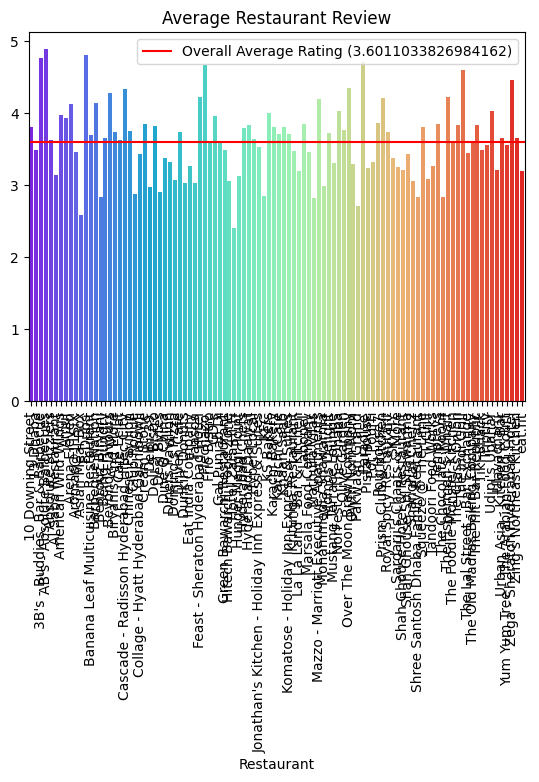

In [7]:
avg_rating = r.groupby("Restaurant")["Rating"].mean()
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="rainbow")
plt.axhline(
    np.mean(avg_rating.values),
    color="red",
    label=f"Overall Average Rating ({np.mean(avg_rating.values)})",
)
plt.xticks(rotation=90)
plt.legend()
plt.title("Average Restaurant Review")
plt.show()

In [8]:
data = r[["Restaurant", "Reviewer", "Review", "Rating"]]
data.head()

,Restaurant,Reviewer,Review,Rating
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5


# Limpieza de texto

In [13]:
import tensorflow as tf
import re
import warnings

warnings.filterwarnings("ignore")
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords

plt.rcParams["figure.figsize"] = (18, 12)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\juanf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# 'clean_text' that processes and cleans text data
stop = set(stopwords.words("english"))


def clean_text(txt, stop=stop):
    if not isinstance(txt, str):
        txt = str(txt)
    txt = txt.lower()
    txt = re.sub(r"\\[nt]*", " ", txt)  # removes \n and \t tags
    txt = re.sub(r"[^A-Za-z\s]", " ", txt)  # removes numbers and other non textual data
    txt = re.sub(r"[\s+]", " ", txt)  # removes multiple whitespaces
    txt = " ".join([x for x in txt.split(" ") if x not in stop])
    return txt

In [ ]:
data["clean_review"] = data["Review"].progress_apply(clean_text)

  0%|          | 0/9810 [00:00<?, ?it/s]

## Target

In [ ]:
data["Rating"] = data["Rating"].apply(float)

In [ ]:
data["Target"] = data["Rating"].progress_apply(lambda x: 1 if x > 3.0 else 0)
data.head()

  0%|          | 0/9810 [00:00<?, ?it/s]

,Restaurant,Reviewer,Review,Rating,clean_review,Target
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,ambience good food quite good saturday lunc...,1
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,ambience good pleasant evening service prompt...,1
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,must try great food great ambience thnx ser...,1
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,soumen das arun great guy behavior sincerety ...,1
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,food good ordered kodi drumsticks basket mutto...,1


## Lematizacion

In [24]:
import spacy


In [ ]:
nlp = spacy.load("en_core_web_sm")


def lemmatize_review(txt, nlp=nlp):
    words = nlp(txt)
    txt = " ".join(word.lemma_ for word in words)
    return txt

In [28]:
data["clean_review"] = data["clean_review"].progress_apply(lemmatize_review)


  0%|          | 0/9810 [00:00<?, ?it/s]

In [29]:
data.head()

,Restaurant,Reviewer,Review,Rating,clean_review,Target
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,ambience good food quite good saturday lu...,1
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,ambience good pleasant evening service promp...,1
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,must try great food great ambience thnx s...,1
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,soumen das arun great guy behavior sincerety...,1
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,food good order kodi drumstick basket mutton b...,1


# clasificacion por TFIDF

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data["clean_review"])
y = data["Target"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# Entrenamiento con LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Métricas
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8726

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.77      0.82       714
           1       0.88      0.93      0.90      1248

    accuracy                           0.87      1962
   macro avg       0.87      0.85      0.86      1962
weighted avg       0.87      0.87      0.87      1962


Confusion Matrix:
 [[ 553  161]
 [  89 1159]]


# Clasificacion con IAG

In [ ]:
import requests
import json


In [37]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "qwen2:1.5b"


def classify_with_ollama(text):
    prompt = f"""
    Eres un clasificador experto de reseñas de restaurantes.
    Analiza el siguiente texto y clasifica su sentimiento como POSITIVO o NEGATIVO.
    Responde SOLO con una palabra: POSITIVO o NEGATIVO.

    Texto: {text}
    """
    payload = {"model": MODEL, "prompt": prompt, "stream": False}
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=30)
        response.raise_for_status()
        result = response.json()["response"].strip().lower()
        return 0 if "positivo" in result else 1
    except Exception as e:
        print(f"Error al llamar a Ollama: {e}")
        return None


In [ ]:
y_true_ollama = data["Target"].tolist()
y_pred_ollama = (
    data["clean_review"]
    .progress_apply(lambda text: classify_with_ollama(text))
    .tolist()
)
y_pred_ollama = [p for p in y_pred_ollama if p is not None]  # Filtrar errores


  0%|          | 0/9810 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Métricas
print(
    "Accuracy (Ollama):",
    round(accuracy_score(y_true_ollama[: len(y_pred_ollama)], y_pred_ollama), 4),
)
print(
    "\nClassification Report (Ollama):\n",
    classification_report(y_true_ollama[: len(y_pred_ollama)], y_pred_ollama),
)
print(
    "\nConfusion Matrix (Ollama):\n",
    confusion_matrix(y_true_ollama[: len(y_pred_ollama)], y_pred_ollama),
)

In [40]:
y_pred_ollama

[1, 0, 1, 0, 0, 0, 1, 0, 1, 1]

In [ ]:
# Instalar transformers si no está disponible
try:
    import transformers

    print("Transformers ya está instalado")
except ImportError:
    import subprocess

    subprocess.check_call(
        ["uv", "add", "transformers", "torch", "accelerate"], stdout=subprocess.DEVNULL
    )
    import transformers

import torch
from transformers import pipeline

# Verificar GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Usando dispositivo: {'GPU' if device == 0 else 'CPU'}")

# Cargar modelo con GPU
classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
)


# Función para clasificar
def classify_with_hf(text):
    result = classifier(text, truncation=True, max_length=512)
    # Mapear etiquetas del modelo a nuestro target (0=positivo, 1=negativo)
    return 0 if result[0]["label"] == "POSITIVE" else 1

In [ ]:
# Clasificar TODO el dataset con Hugging Face (GPU)
y_true_hf = data["Target"].tolist()
y_pred_hf = (
    data["clean_review"].progress_apply(lambda text: classify_with_hf(text)).tolist()
)

# Métricas
print("Accuracy (Hugging Face):", round(accuracy_score(y_true_hf, y_pred_hf), 4))
print(
    "\nClassification Report (Hugging Face):\n",
    classification_report(y_true_hf, y_pred_hf),
)
print("\nConfusion Matrix (Hugging Face):\n", confusion_matrix(y_true_hf, y_pred_hf))